# Goal

Get the Lasair API to work and try a query.  



Some useful links:   

API client: https://lasair-lsst.readthedocs.io/en/main/core_functions/client.html    
Example notebooks: https://github.com/lsst-uk/lasair-examples/tree/main/lsst_notebooks  
Specifically for notebooks: https://github.com/lsst-uk/lasair-examples/tree/main/lsst_notebooks/api  
Lasair LSST schema browser: https://lasair.lsst.ac.uk/schema/#objects_ext-schema  


Example to get fits cutouts: https://community.lsst.org/t/does-lasair-provide-and-store-cutouts-for-all-alerts-including-past-ones/11002  
Also see: https://community.lsst.org/t/invalid-cutout-fits-files/11626/4  
NOTE: They only seem to be stored for a month?

## Imports and settings

In [1]:
from lasair import LasairError, lasair_client as lasair
import settings
import json
import os 
import wget
import numpy as np
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

In [2]:
endpoint = "https://api.lasair.lsst.ac.uk/api"
L = lasair(settings.API_TOKEN, endpoint=endpoint)

## Code

##### Simple query

In [3]:
selected = 'objects.diaObjectId, objects.ra, objects.decl' 
tables = 'objects,sherlock_classifications'
conditions = 'classification="SN"'
results = L.query(selected, tables, conditions, limit = 8)

for row in results:
    objectId = row['diaObjectId']
    ra = row['ra']
    dec = row['decl']
    print(objectId, ra, dec)

# Just use this objectId in subsequent calls
objectId = results[0]['diaObjectId']

170019696254910754 62.00489102706123 -49.480107426965155
170019696255435601 61.968117601750194 -49.66424587878178
170019696255435832 61.870113867720846 -49.658723098270656
170019696256483349 62.034412310614165 -49.402104967251574
170019696256483390 61.88140266821427 -49.424357557495945
170019696256483399 62.080921093801514 -49.282687331866626
170019696256483574 62.01929036473879 -49.237942868780024
170019696262250510 60.76849698105053 -50.18300373874268


In [4]:
results

[{'diaObjectId': 170019696254910754,
  'ra': 62.00489102706123,
  'decl': -49.480107426965155},
 {'diaObjectId': 170019696255435601,
  'ra': 61.968117601750194,
  'decl': -49.66424587878178},
 {'diaObjectId': 170019696255435832,
  'ra': 61.870113867720846,
  'decl': -49.658723098270656},
 {'diaObjectId': 170019696256483349,
  'ra': 62.034412310614165,
  'decl': -49.402104967251574},
 {'diaObjectId': 170019696256483390,
  'ra': 61.88140266821427,
  'decl': -49.424357557495945},
 {'diaObjectId': 170019696256483399,
  'ra': 62.080921093801514,
  'decl': -49.282687331866626},
 {'diaObjectId': 170019696256483574,
  'ra': 62.01929036473879,
  'decl': -49.237942868780024},
 {'diaObjectId': 170019696262250510,
  'ra': 60.76849698105053,
  'decl': -50.18300373874268}]

##### More relevant query

In [6]:
selected = '''
        objects.diaObjectId,
       objects.ra,
       objects.decl,
       mjdnow()-objects.lastDiaSourceMjdTai AS since,
       objects.lastDiaSourceMjdTai,
       objects.latestR,
       objects.nDiaSources,
       sherlock_classifications.classification,
       sherlock_classifications.association_type,
       sherlock_classifications.distance,
       sherlock_classifications.z,
       sherlock_classifications.classificationReliability,
       sherlock_classifications.major_axis_arcsec,
       sherlock_classifications.separationArcsec

'''

tables = 'objects,sherlock_classifications'


conditions = '''
    objects.diaObjectId=sherlock_classifications.diaObjectId
  AND objects.diaObjectId=sherlock_classifications.diaObjectId
  AND sherlock_classifications.classification IN ("SN")
  AND mjdnow() - objects.lastDiaSourceMjdTai <= 1
  '''



results = L.query(selected, tables, conditions, limit = 8)

for row in results:
    objectId = row['diaObjectId']
    ra = row['ra']
    dec = row['decl']
    print(objectId, ra, dec)

# Just use this objectId in subsequent calls
diaObjectId = results[1]['diaObjectId']

170019696266444924 59.89904189970023 -50.459670178667224
170019696272736349 61.49711234522624 -49.24578783339325
170019696276406393 60.67436623353616 -49.02812464458933
170019696277454855 60.85379492201429 -49.808465608732654
170019696282173491 59.88621117604273 -50.32530976476144
170019696288465031 58.74885180152817 -50.62315557392915
170019696293183617 61.16045486297991 -48.08925471842978
170019696293707856 60.908248877448074 -48.31839552451119


In [7]:
# Just use this objectId in subsequent calls
diaObjectId = results[0]['diaObjectId']
print(diaObjectId)

170019696266444924


In [8]:
diaObjectId = 170019696262250510

In [16]:
# Get fits from first object

objResult = L.object(diaObjectId, lasair_added=True)

In [17]:
objResult

{'diaObjectId': '170019696262250510',
 'lasairData': {'nDiaSources': 18,
  'firstDiaSourceMjdTai': 61088.098045202045,
  'lastDiaSourceMjdTai': 61096.04480987982,
  'glat': -47.0748,
  'ebv': 0.0113328,
  'rasex': '04:03:4.439',
  'decsex': '-50:10:58.813',
  'ec_lon': 33.52284843077866,
  'ec_lat': -67.96993839238424,
  'g_lon': 258.6869784183863,
  'g_lat': -47.07476248702014,
  'now_mjd': '61097.58',
  'mjdmin_ago': 9.485720133503492,
  'mjdmax_ago': 1.5389554557259544,
  'discMjd': 61088.098045202045,
  'discUtc': '2026-02-17 02:21:11',
  'discMag': '1052.75±172.96',
  'discFilter': 'r',
  'latestMjd': 61096.04480987982,
  'latestUtc': '2026-02-25 01:04:31',
  'latestMag': '1491.21±199.45',
  'latestFilter': 'r',
  'peakMjd': 61091.028789931544,
  'peakUtc': '2026-02-20 00:41:27',
  'peakMag': '1638.64±246.23',
  'peakFilter': 'i',
  'sherlock': {'diaObjectId': 170019696262250510,
   'classification': 'SN',
   'association_type': 'SN',
   'catalogue_table_name': 'DESI',
   'catalog

In [18]:
objResult.keys()

dict_keys(['diaObjectId', 'lasairData', 'diaObject', 'diaSourcesList', 'diaForcedSourcesList'])

In [19]:
len(objResult['diaSourcesList'])

18

In [20]:
idx = np.argmax([objResult['diaSourcesList'][i]['midpointMjdTai'] for i in range(len(objResult['diaSourcesList']))]) # get the latest

In [21]:
objResult['diaSourcesList'][idx]['midpointMjdTai']

61096.04480987982

In [22]:
urls = objResult['lasairData']['imageUrls']

In [23]:
urls

[{'Science': 'https://lasair.lsst.ac.uk/fits/170054922241310762_cutoutScience',
  'Template': 'https://lasair.lsst.ac.uk/fits/170054922241310762_cutoutTemplate',
  'Difference': 'https://lasair.lsst.ac.uk/fits/170054922241310762_cutoutDifference',
  'diaSourceId': 170054922241310762},
 {'Science': 'https://lasair.lsst.ac.uk/fits/170054918485835895_cutoutScience',
  'Template': 'https://lasair.lsst.ac.uk/fits/170054918485835895_cutoutTemplate',
  'Difference': 'https://lasair.lsst.ac.uk/fits/170054918485835895_cutoutDifference',
  'diaSourceId': 170054918485835895},
 {'Science': 'https://lasair.lsst.ac.uk/fits/170050486209609781_cutoutScience',
  'Template': 'https://lasair.lsst.ac.uk/fits/170050486209609781_cutoutTemplate',
  'Difference': 'https://lasair.lsst.ac.uk/fits/170050486209609781_cutoutDifference',
  'diaSourceId': 170050486209609781},
 {'Science': 'https://lasair.lsst.ac.uk/fits/170050484061601936_cutoutScience',
  'Template': 'https://lasair.lsst.ac.uk/fits/1700504840616019

In [24]:
# Need to select correct diaSource! 

In [25]:
idx

np.int64(0)

In [32]:
idx = 0

science_url = urls[idx]['Science']#+'.fits'
out_path = 'data/temp'+'.fits'

wget.download(science_url, out=out_path)

'data/temp.fits'

In [33]:
science_url

'https://lasair.lsst.ac.uk/fits/170054922241310762_cutoutScience'

In [34]:
science_url.rsplit('.', 1)

['https://lasair.lsst.ac', 'uk/fits/170054922241310762_cutoutScience']

In [35]:
# url = 'https://lasair-dev.lsst.ac.uk/lasair/static/fits/fa9/2240410792515015000_cutoutScience.fits'
# out_path = 'data/temp.txt'

# wget.download(science_url, out=out_path)

In [44]:
ff = fits.open(out_path)
ff

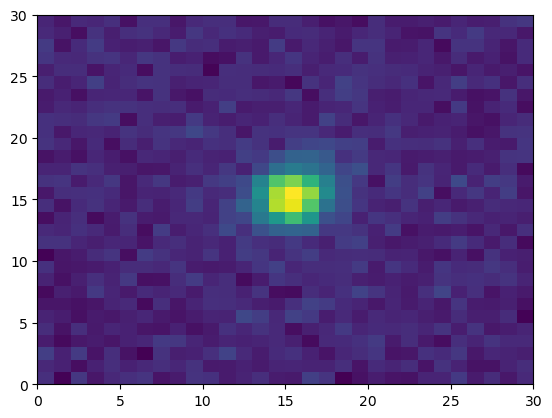

In [45]:
plt.pcolormesh(ff[0].data)

In [49]:
lite=False
result = L.sherlock_object(diaObjectId, lite=lite)
#print15(json.dumps(result, indent=2))

In [50]:
result

{'classifications': {'170019696262250510': ['SN',
   'The transient is possibly associated with <em>10000,76589,11715</em>; an r=21.35 mag galaxy found in the DESI catalogue. It\'s located 0.02" N, 0.09" E from the galaxy centre.']},
 'crossmatches': [{'W1': 19.6752,
   'W1Err': 0.0628742,
   'W2': 19.644,
   'W2Err': 0.0628742,
   'W3': 18.5549,
   'W3Err': 0.417896,
   'W4': 14.0209,
   'W4Err': 0.118691,
   '_g': 21.9669,
   '_gErr': 0.0145457,
   '_i': 21.0831,
   '_iErr': 0.0128316,
   '_r': 21.3542,
   '_rErr': 0.008901,
   '_z': 20.4957,
   '_zErr': 0.0114453,
   'association_type': 'SN',
   'best_distance': None,
   'best_distance_flag': None,
   'best_distance_source': None,
   'catalogue_object_id': '10000,76589,11715',
   'catalogue_object_subtype': 'REX',
   'catalogue_object_type': 'galaxy',
   'catalogue_table_id': 84,
   'catalogue_table_name': 'DESI',
   'catalogue_view_id': 58,
   'catalogue_view_name': 'tcs_view_galaxy_desi_legacy_dr10',
   'classificationReliability'

# Download fits files from ALeRCE instead

I downloaded the fits files from alerce instead, for object X using this link: https://lsst.alerce.online/object/170019696262250510?oid=170019696262250510&survey=lsst&page=1&page_size=20&count=false&selected_oid=170019696262250510

In [212]:
science_fileloc = 'data/170019696262250510_170054922241310762_science.fits.gz'
template_fileloc = 'data/170019696262250510_170054922241310762_template.fits.gz'
difference_fileloc = 'data/170019696262250510_170054922241310762_difference.fits.gz'

lasair_fileloc = 'data/170054922241310762_cutoutScience_lasair.fits'

In [218]:
# Open the file

hdul = fits.open(difference_fileloc)
hdul.info()  # See the structure (extensions)

Filename: data/170019696262250510_170054922241310762_difference.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (30, 30)   float32   
  1  UNCERT        1 ImageHDU         9   (30, 30)   float32   
  2  PSFIMAGE      1 ImageHDU         8   (41, 41)   float64   


In [219]:
hdul.info()

Filename: data/170019696262250510_170054922241310762_difference.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (30, 30)   float32   
  1  UNCERT        1 ImageHDU         9   (30, 30)   float32   
  2  PSFIMAGE      1 ImageHDU         8   (41, 41)   float64   


In [220]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   30                                                  
NAXIS2  =                   30                                                  
EXTEND  =                    T                                                  
CUTMINX =                  624                                                  
CUTMINY =                  879                                                  
ROTPA   =     328.530439924614 / Pos angle in deg of focal plane +Y wrt North   
BUNIT   = 'nJy     '                                                            
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =      15.574966390063 / Pixel coordinate of reference point            
CRPIX2  =      15.9253270911

In [221]:
hdul[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   30                                                  
NAXIS2  =                   30                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
UTYPE   = 'VarianceUncertainty'                                                 
EXTNAME = 'UNCERT  '           / extension name                                 

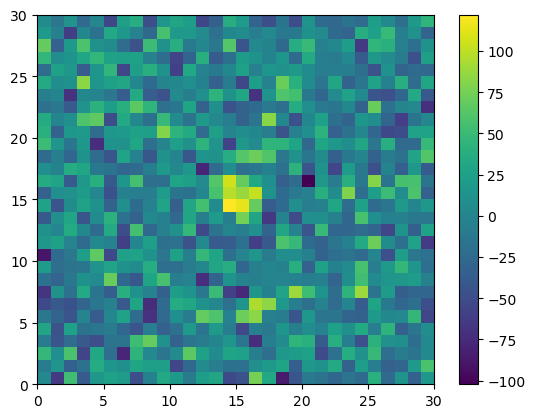

In [222]:
plt.pcolormesh(hdul[0].data)
plt.colorbar()
plt.show()

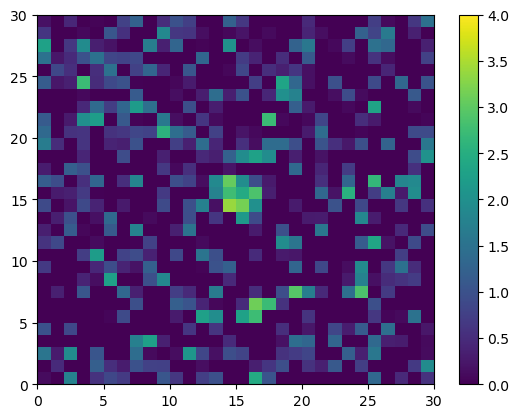

In [225]:
plt.pcolormesh(hdul[0].data/np.sqrt(hdul[1].data), vmin = 0, vmax = 4)
plt.colorbar()
plt.show()

# Download from ALeRCE

API client: https://alerce.readthedocs.io/en/latest/index.html  
Notebook examples: https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb  



Some ALeRCE terminology:

`oid`: identifier for each object. Can either be `diaObjectId` (for non-moving objects such as SNe, AGN, variable stars, ...) or `ssObjectID` for Solar System moving objects.  
`measurement_id`: Way to disentangle epochs from a oid. So in practise it is equal to `diaSourceId` or `diaForcedSourceId`.  
`tid`: Telescope identifier. Rubin LSST has tid = 1  
`sid`: Survey identifier. Should be 1 for objects that have diaObjects. Will be 2 for solar system stuff.  

In [285]:
from alerce.core import Alerce

In [286]:
diaObjectId = 170019696262250510
diaSourceId = 170054922241310762

In [287]:
alerce_client = Alerce()

In [288]:
tid = 1 #Telescope identifier. LSST and Rubin have tid = 1
sid = 1 #Survey identifier. Should be 1 for objects that have diaObjects. Will be 2 for solar system stuff.

In [289]:
df_obj = alerce_client.query_object(oid=diaObjectId, survey='lsst', format='pandas')

In [290]:
df_obj

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,170019696262250510,1,1,60.768499,-50.183007,0.000005,0.000005,61088.098045,61096.04481,7.946765,18,172,0,2026-02-17T00:00:00,2026-02-25T00:00:00


In [293]:
df_dets = alerce_client.query_forced_photometry(oid=diaObjectId, survey='lsst',format='pandas')
df_dets

,band,mjd,survey_id,oid,measurement_id,ra,dec,visit,detector,psfFlux,psfFluxErr,scienceFlux,scienceFluxErr,band_name
0,1,61090.067768,lsst,170019696262250510,170028490068328553,60.768629,-50.182947,2026021800089,7,587.29730,144.39203,5275.8438,129.09958,g
1,1,61090.070364,lsst,170019696262250510,170028490880975027,60.768629,-50.182947,2026021800095,21,474.71347,158.84674,5349.8590,142.43605,g
2,1,61090.072099,lsst,170019696262250510,170028491413127318,60.768629,-50.182947,2026021800099,12,137.34512,149.82574,5072.9644,133.06654,g
3,1,61090.073242,lsst,170019696262250510,170028491692048516,60.768629,-50.182947,2026021800101,32,115.62470,159.53888,5234.9070,143.01094,g
4,1,61090.074109,lsst,170019696262250510,170028491946852375,60.768629,-50.182947,2026021800103,6,366.07907,157.50078,5328.9610,140.83316,g
5,4,61090.077276,lsst,170019696262250510,170028492518326429,60.768629,-50.182947,2026021800107,72,-538.30524,391.42840,16380.0670,379.06607,z
6,4,61090.078140,lsst,170019696262250510,170028492763693124,60.768629,-50.182947,2026021800109,28,566.21340,419.39246,18534.3280,405.01700,z
7,4,61090.079869,lsst,170019696262250510,170028493305282607,60.768629,-50.182947,2026021800113,37,317.74680,421.94962,18466.2560,410.00214,z
8,4,61090.080739,lsst,170019696262250510,170028493557989489,60.768629,-50.182947,2026021800115,7,201.42052,402.46720,17590.0020,387.50305,z
9,4,61090.081727,lsst,170019696262250510,170028493843202247,60.768629,-50.182947,2026021800117,39,1210.61800,431.35046,19278.6330,419.26462,z


In [261]:
cutouts = alerce_client.get_stamps(
    oid=diaObjectId,
    measurement_id=diaSourceId,
    survey="lsst",
    include_variance_and_mask=True # Note: the API and examples (https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb) say that in the future this argument might be renamedto include_variance_and_psf, because it is a PSF and not a mask.
)

In [263]:
fitsfile = cutouts['cutoutScience']

In [264]:
fitsfile

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x782fc82ae8a0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fc82ac380>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fc840bf50>]

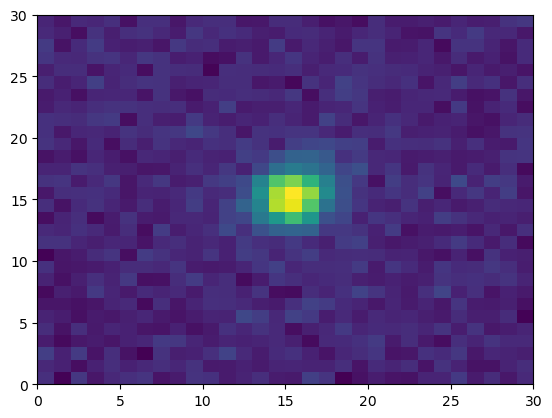

In [266]:
plt.pcolormesh(fitsfile[0].data)

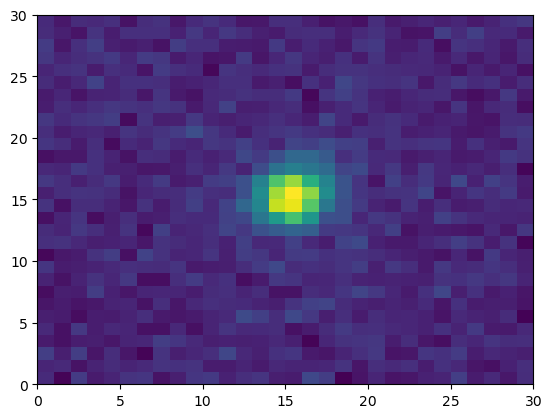

In [267]:
plt.pcolormesh(fitsfile[1].data)

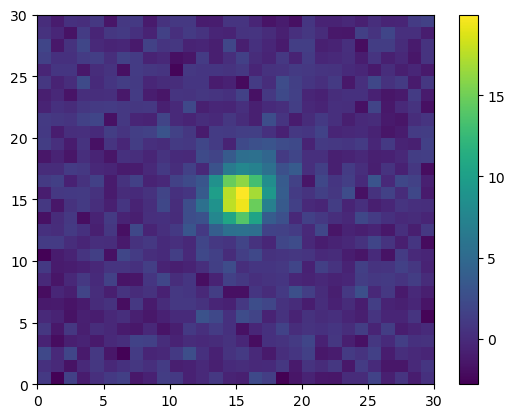

In [276]:
plt.pcolormesh(fitsfile[0].data/np.sqrt(fitsfile[1].data))
plt.colorbar()
plt.show()

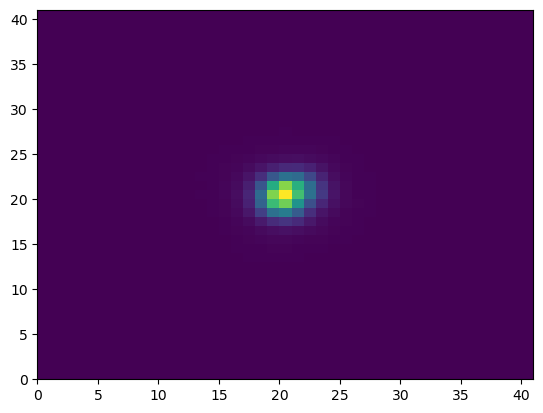

In [273]:
plt.pcolormesh(fitsfile[2].data)

# Try this out for a bunch

In [380]:
def plot_main_figure(calexp, template, diff, zoom_size = 30, ncol =4, nrow = 1, col = 'red',  titles_fontsize = 22, figsize = (4,4.3), plot = True, scale = 'asinh'):
    '''
    calexp, template, and diff should be a list of fits files, with 0 being the values, 1 the variance, and 2 the psf mask (not used)
    '''


    calexp_cutout = calexp[0].data
    template_cutout = template[0].data
    diff_cutout = diff[0].data
    snr = diff[0].data/np.sqrt(diff[1].data)


    zoom_size = calexp_cutout.shape[0]
    

    x = zoom_size / 2 # Just put it in middle lol
    y = zoom_size / 2

    


    vmin_p = 30
    vmax_p = 99


    plt.figure(figsize = (figsize[0]*ncol, figsize[1]*nrow))

    plt.subplot(nrow,ncol,1)
    vmin = np.percentile(template_cutout, vmin_p)
    vmax = np.percentile(template_cutout, vmax_p)
    # vmin = np.percentile(calexp_cutout, vmin_p)
    # vmax = np.percentile(calexp_cutout, vmax_p)
        
    plt.imshow(calexp_cutout, origin = 'lower', norm =scale, cmap = 'grey', vmin = vmin, vmax = vmax)
    draw_crosshair(plt.gca(), x,y, L=zoom_size/10, gap=zoom_size/20, color=col, linewidth=2)
    #plt.colorbar()
    plt.title('Science Image', fontsize= titles_fontsize)
    plt.xticks([])
    plt.yticks([])
        
    plt.subplot(nrow,ncol,2)
    vmin = np.percentile(template_cutout, vmin_p)
    vmax = np.percentile(template_cutout, vmax_p)
    
    plt.imshow(template_cutout, origin = 'lower', norm =scale, cmap = 'grey', vmin = vmin, vmax = vmax)
    draw_crosshair(plt.gca(), x,y, L=zoom_size/10, gap=zoom_size/20, color=col, linewidth=2)
    #plt.colorbar()
    plt.title('Template Image', fontsize= titles_fontsize)
    plt.xticks([])
    plt.yticks([])

    
    plt.subplot(nrow,ncol,3)
    vmin = np.percentile(diff_cutout, 1)
    vmax = np.percentile(diff_cutout, 99)
    
    plt.imshow(diff_cutout, origin = 'lower', norm ='linear', cmap = 'grey', vmin = vmin, vmax = vmax)
    draw_crosshair(plt.gca(), x,y, L=zoom_size/10, gap=zoom_size/20, color=col, linewidth=2)
    #plt.colorbar()
    plt.title('Difference Image', fontsize= titles_fontsize)
    plt.xticks([])
    plt.yticks([])
    
        
    plt.subplot(nrow, ncol, 4)
    plt.imshow(snr, origin = 'lower', norm ='linear', cmap = 'viridis', vmin = 0, vmax = 5)
    draw_crosshair(plt.gca(), x,y, L=zoom_size/10, gap=zoom_size/20, color=col, linewidth=2)
    plt.title('SNR Map', fontsize= titles_fontsize)
    #plt.colorbar()
    plt.xticks([])
    plt.yticks([])

    
    plt.tight_layout()
    plt.show()




def draw_crosshair(ax, x, y, L=0.2, gap=0.05, **kwargs):
    ax.plot([x - L - gap, x - gap], [y, y], **kwargs)
    ax.plot([x + gap, x + L + gap], [y, y], **kwargs)
    ax.plot([x, x], [y - L - gap, y - gap], **kwargs)
    ax.plot([x, x], [y + gap, y + L + gap], **kwargs)



In [318]:
### Part 1: Use Lasair to query a good diaObject. Note that you don't get your DiaSources from here though.
mjd_now = Time.now().mjd
delta_t = 1

selected = '''
        objects.diaObjectId,
       objects.ra,
       objects.decl,
       mjdnow()-objects.lastDiaSourceMjdTai AS since,
       objects.lastDiaSourceMjdTai,
       objects.latestR,
       objects.nDiaSources,
       sherlock_classifications.classification,
       sherlock_classifications.association_type,
       sherlock_classifications.distance,
       sherlock_classifications.z,
       sherlock_classifications.classificationReliability,
       sherlock_classifications.major_axis_arcsec,
       sherlock_classifications.separationArcsec
 
'''

tables = 'objects,sherlock_classifications'


conditions = f'''
    objects.diaObjectId=sherlock_classifications.diaObjectId
  AND objects.diaObjectId=sherlock_classifications.diaObjectId
  AND sherlock_classifications.classification IN ("SN")
  AND mjdnow() - objects.lastDiaSourceMjdTai <= {delta_t}
  '''



results = L.query(selected, tables, conditions, limit = 10)
diaObjectIds = [results[i]['diaObjectId'] for i in range(len(results))]

In [319]:
idx_diaobj = 0 # Make this for-loop
diaObjectId = diaObjectIds[idx_diaobj]

objResult = L.object(diaObjectId, lasair_added=False)# Get more info of this object specifically to find all of its diaSources

In [320]:
objResult

{'diaObjectId': '170019696262250510',
 'diaSourcesList': [{'diaSourceId': 170019696262250510,
   'midpointMjdTai': 61088.098045202045,
   'band': 'r',
   'psfFlux': 1052.7470703125,
   'psfFluxErr': 172.9615020751953,
   'reliability': 0.20285622775554657},
  {'diaSourceId': 170028490068328532,
   'midpointMjdTai': 61090.067767826775,
   'band': 'g',
   'psfFlux': 682.8624877929688,
   'psfFluxErr': 134.0672607421875,
   'reliability': 0.16682222485542297},
  {'diaSourceId': 170032880200712245,
   'midpointMjdTai': 61091.028789931544,
   'band': 'i',
   'psfFlux': 1638.6409912109375,
   'psfFluxErr': 246.2327880859375,
   'reliability': 0.3981802761554718},
  {'diaSourceId': 170032881808703590,
   'midpointMjdTai': 61091.03416226883,
   'band': 'i',
   'psfFlux': 1263.9305419921875,
   'psfFluxErr': 230.22129821777344,
   'reliability': 0.17871788144111633},
  {'diaSourceId': 170032882619252915,
   'midpointMjdTai': 61091.03675571107,
   'band': 'i',
   'psfFlux': 1213.0643310546875,
 

In [347]:
diaSourceIds = np.array([objResult['diaSourcesList'][i]['diaSourceId'] for i in range(len(objResult['diaSourcesList']))])
mjds = np.array([objResult['diaSourcesList'][i]['midpointMjdTai'] for i in range(len(objResult['diaSourcesList']))])
time_since_mjd = mjd_now - mjds
idx_keep = np.where(time_since_mjd <= delta_t)[0]

diaSourceIds = diaSourceIds[idx_keep]
time_since_mjd = time_since_mjd[idx_keep]

In [331]:
idx_diasource = 0

diaSourceId = diaSourceIds[idx_diasource]

In [332]:
cutouts = alerce_client.get_stamps(
    oid=diaObjectId,
    measurement_id=diaSourceId,
    survey="lsst",
    include_variance_and_mask=True # Note: the API and examples (https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb) say that in the future this argument might be renamedto include_variance_and_psf, because it is a PSF and not a mask.
)

In [338]:
cutouts

{'cutoutScience': [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x782fb75a9310>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fb76518e0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fc82ac230>],
 'cutoutTemplate': [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x782fb6c27620>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fb6c25a00>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fb6c48980>],
 'cutoutDifference': [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x782fb6c48140>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fb6c49bb0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x782fb6c4a180>]}

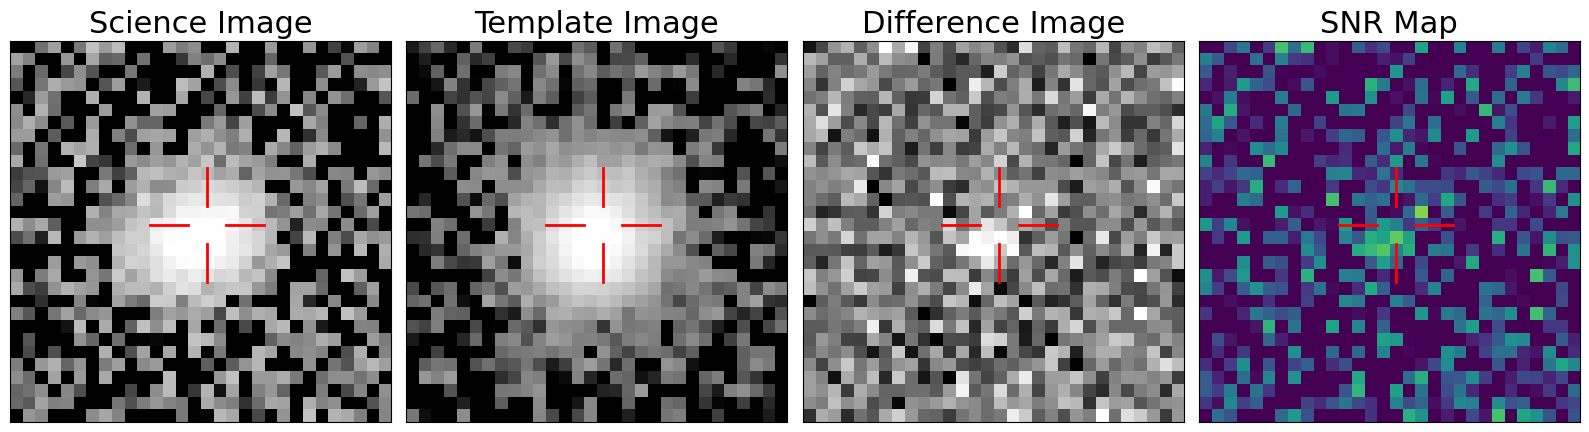

In [345]:
plot_main_figure(cutouts['cutoutScience'],cutouts['cutoutTemplate'], cutouts['cutoutDifference'])

##### Now create a loop

In [351]:
### Part 1: Use Lasair to query a good diaObject. Note that you don't get your DiaSources from here though.
mjd_now = Time.now().mjd
delta_t = 1

selected = '''
        objects.diaObjectId,
       objects.ra,
       objects.decl,
       mjdnow()-objects.lastDiaSourceMjdTai AS since,
       objects.lastDiaSourceMjdTai,
       objects.latestR,
       objects.nDiaSources,
       sherlock_classifications.classification,
       sherlock_classifications.association_type,
       sherlock_classifications.distance,
       sherlock_classifications.z,
       sherlock_classifications.classificationReliability,
       sherlock_classifications.major_axis_arcsec,
       sherlock_classifications.separationArcsec
 
'''

tables = 'objects,sherlock_classifications'


conditions = f'''
    objects.diaObjectId=sherlock_classifications.diaObjectId
  AND objects.diaObjectId=sherlock_classifications.diaObjectId
  AND sherlock_classifications.classification IN ("SN")
  AND mjdnow() - objects.lastDiaSourceMjdTai <= {delta_t}
  '''


results = L.query(selected, tables, conditions, limit = 10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [377]:
### Part 2: then use Lasair to query all diaSources. Save both

diaObjectIds = [results[i]['diaObjectId'] for i in range(len(results))]
data = []

for i in tqdm(range(len(diaObjectIds))):
    diaObjectId = diaObjectIds[i]

    
    objResult = L.object(diaObjectId, lasair_added=False)# Get more info of this object specifically to find all of its diaSources


    diaSourceIds = np.array([objResult['diaSourcesList'][ii]['diaSourceId'] for ii in range(len(objResult['diaSourcesList']))])
    mjds = np.array([objResult['diaSourcesList'][ii]['midpointMjdTai'] for ii in range(len(objResult['diaSourcesList']))])
    time_since_mjd = mjd_now - mjds

    idx_keep = np.where(time_since_mjd <= delta_t)[0] #Find all new epochs for this target
    
    diaSourceIds = diaSourceIds[idx_keep]
    #time_since_mjd = time_since_mjd[idx_keep]


    for j in range(len(diaSourceIds)):
        diaSourceId = diaSourceIds[j]

        data.append({'diaObjectId' : diaObjectId, 'diaSourceId' : diaSourceId})



data = pd.DataFrame(data)
data = data.sample(frac=1).reset_index(drop=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [378]:
data

,diaObjectId,diaSourceId
0,170019696272736349,170054939424850033
1,170019696276406393,170054918760038568
2,170019696282173491,170054921167569016
3,170019696266444924,170054928019488793
4,170019696272736349,170054921866444963
...,...,...
301,170019696272736349,170054937978339333
302,170019696266444924,170054920624930830
303,170019696266444924,170054933660303417
304,170019696272736349,170054923587158139


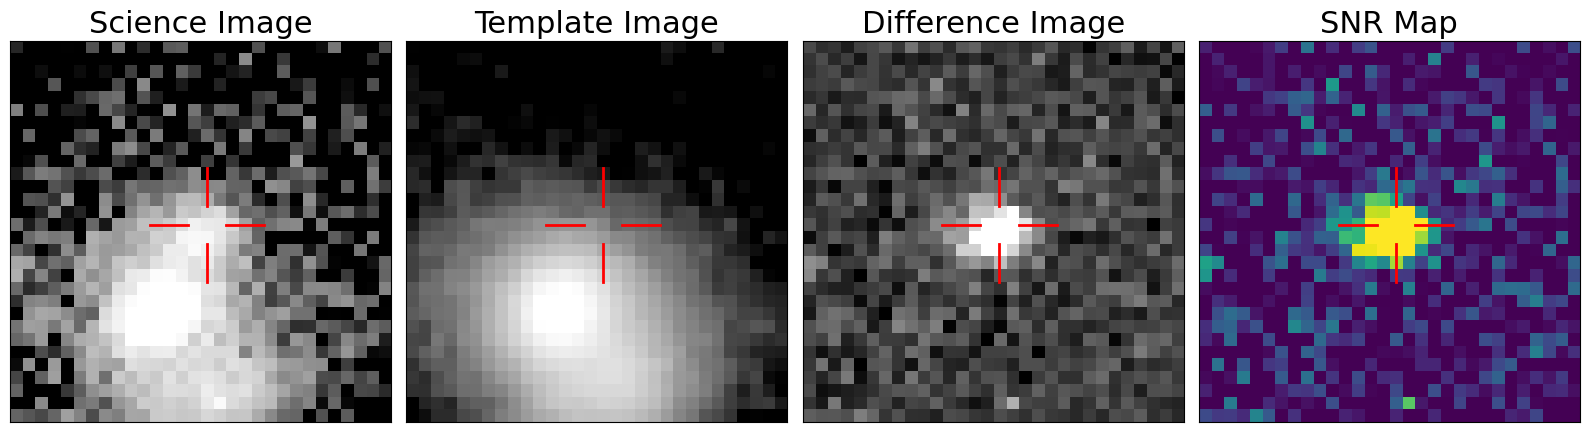

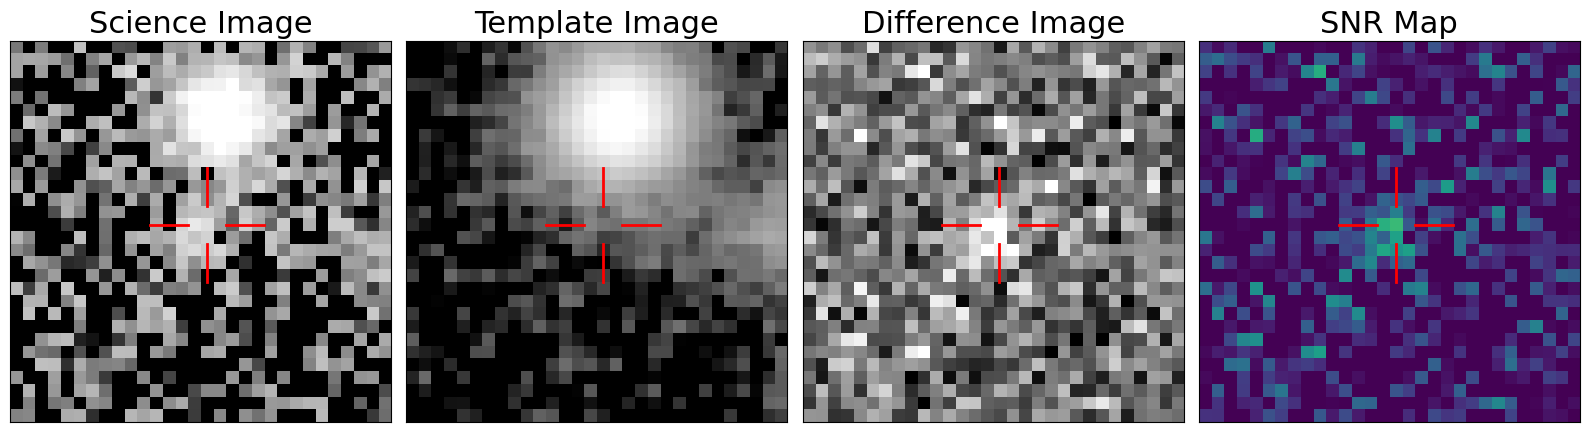

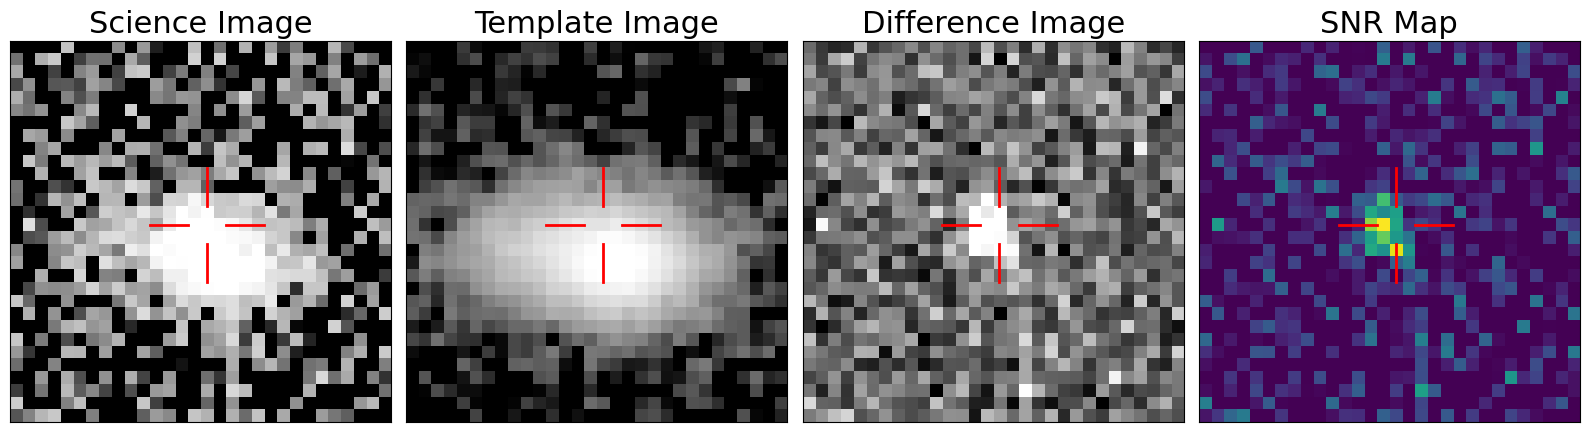

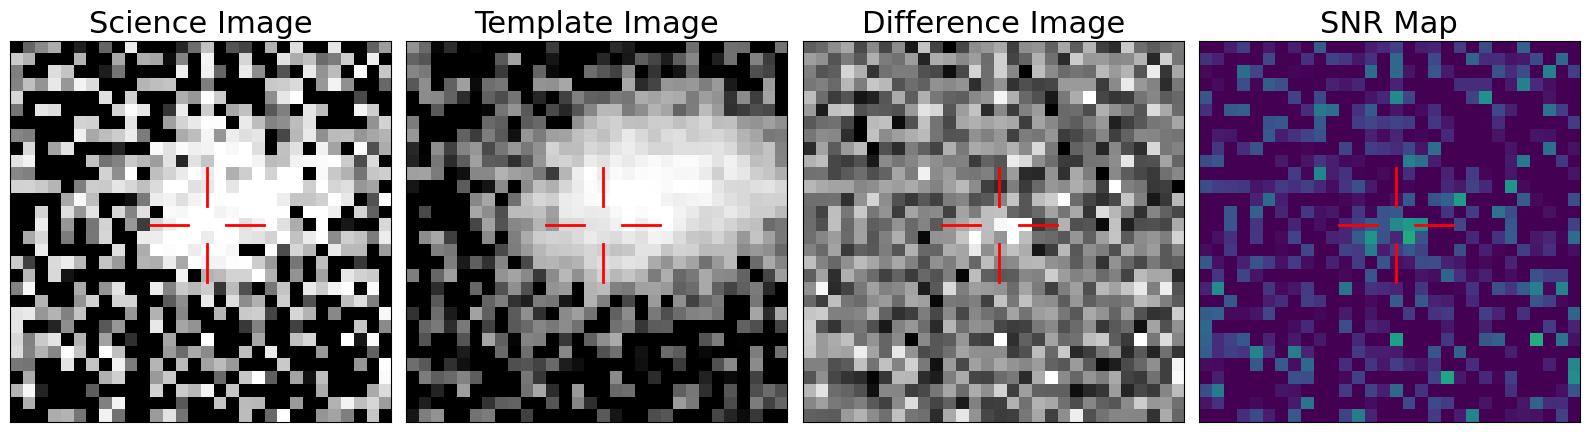

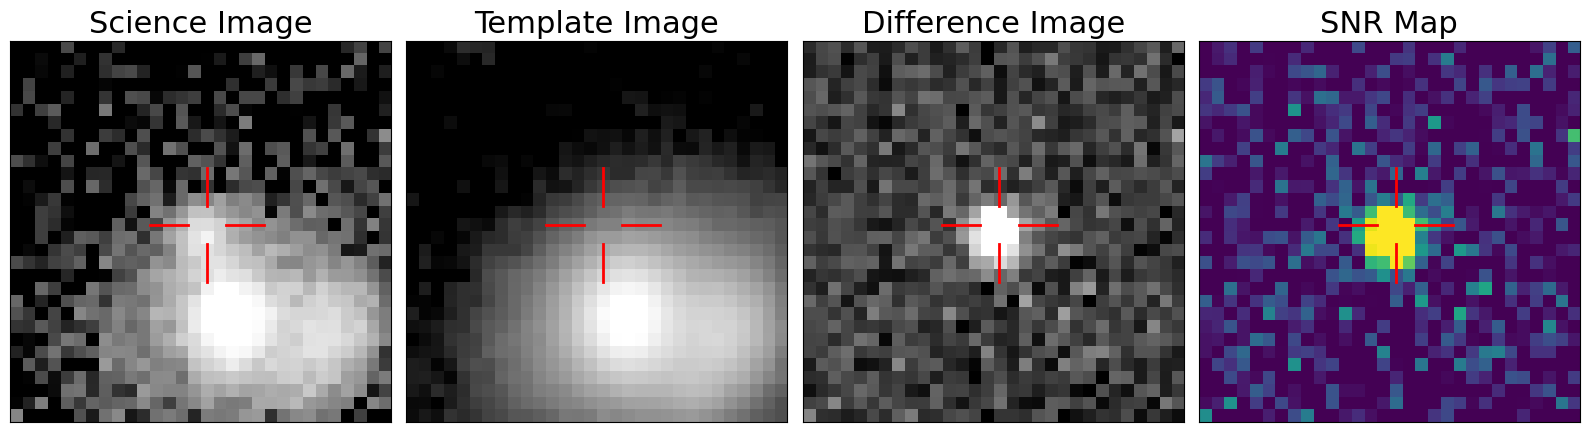

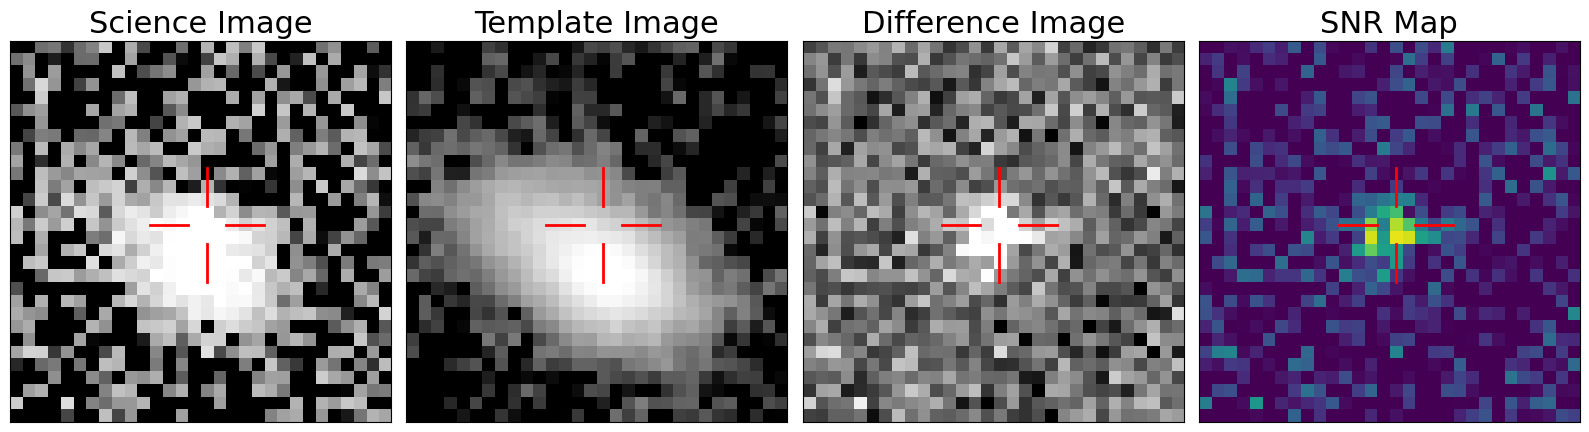

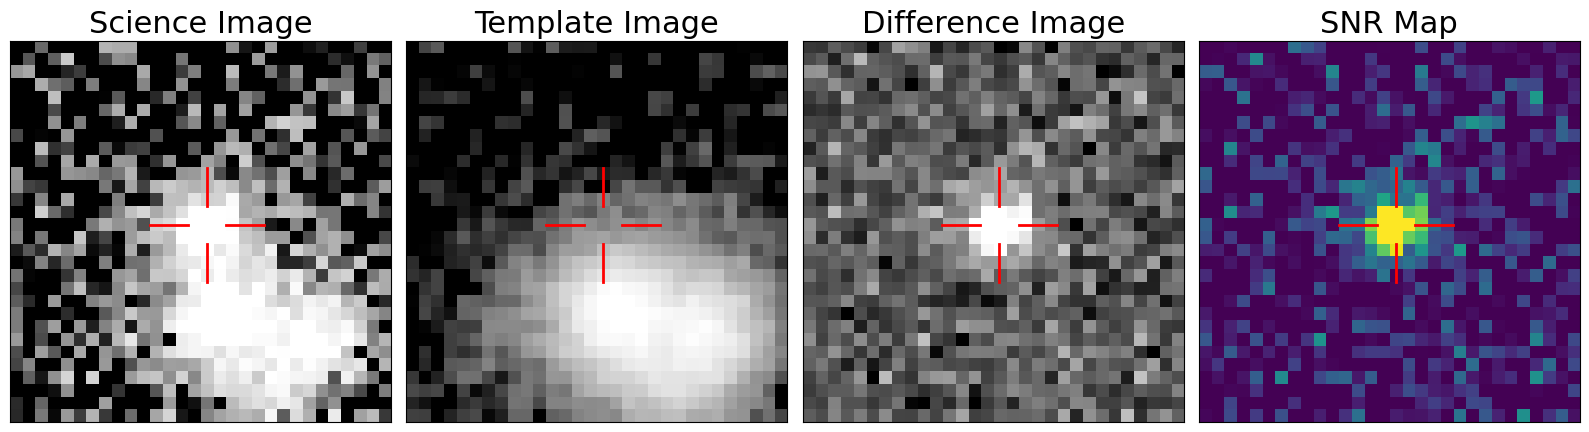

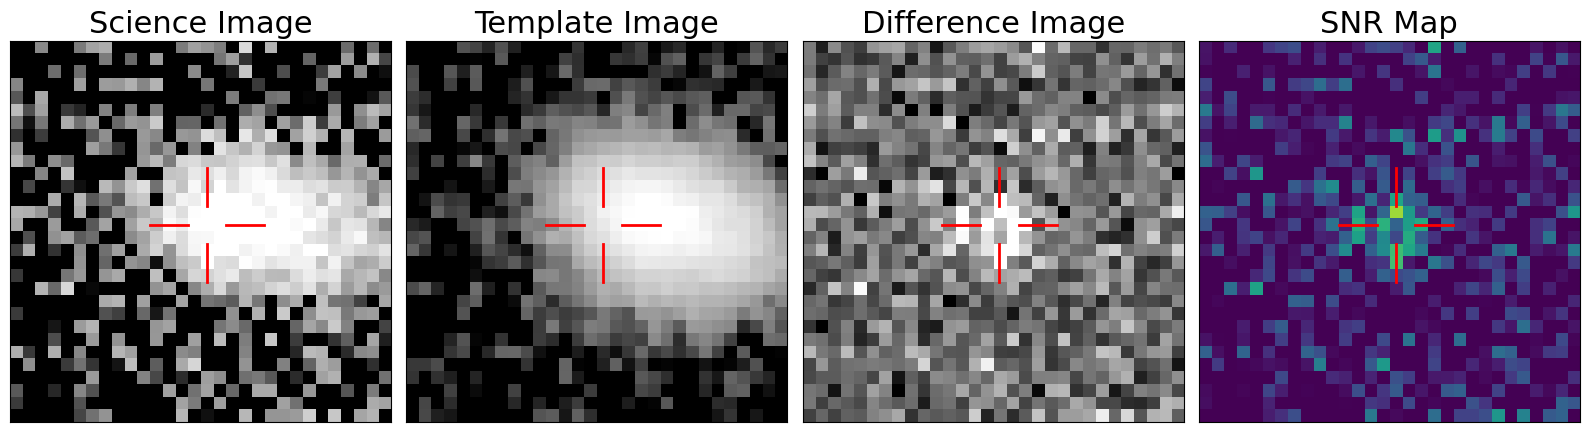

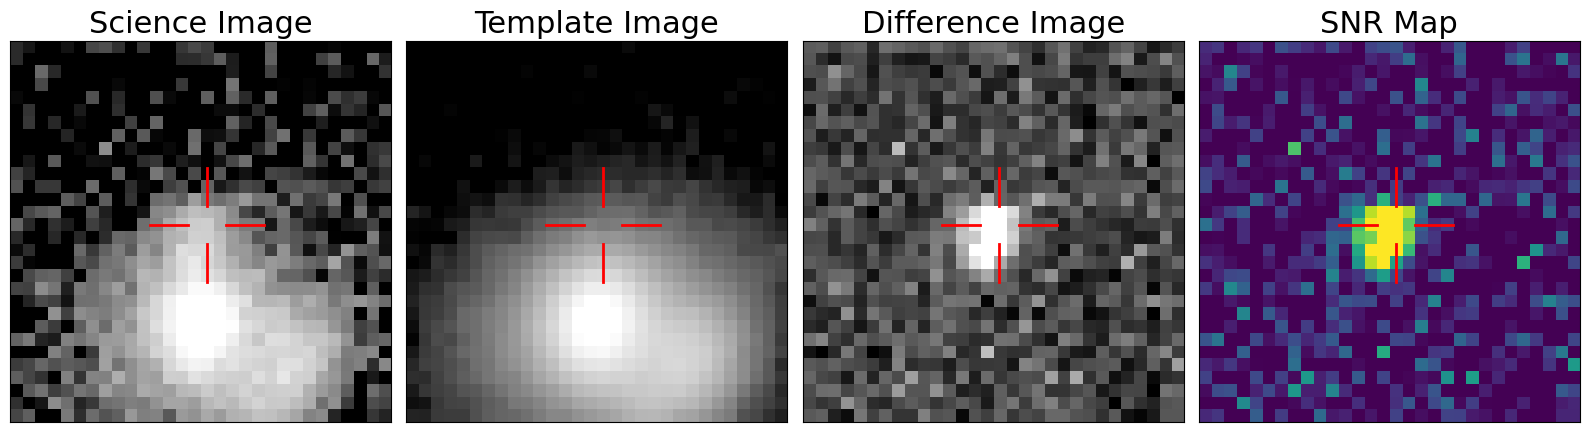

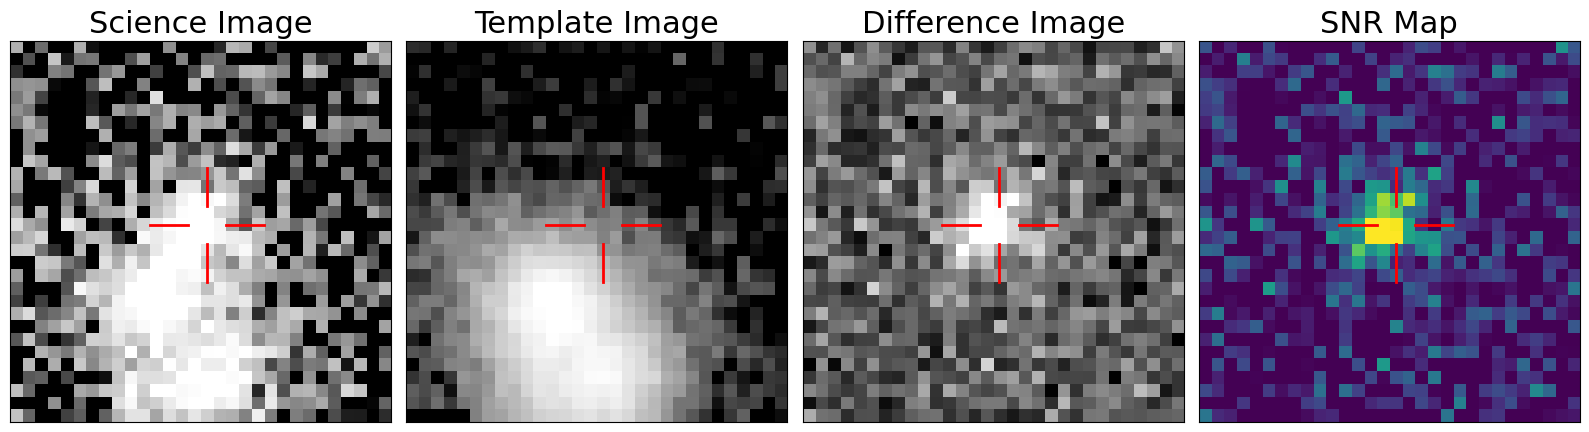

In [381]:
### Part 3: query ALeRCE for its cutouts and plot

for i in range(len(data[:10])):

    diaObjectId = data['diaObjectId'][i]
    diaSourceId = data['diaSourceId'][i]

    cutouts = alerce_client.get_stamps(
        oid=diaObjectId,
        measurement_id=diaSourceId,
        survey="lsst",
        include_variance_and_mask=True # Note: the API and examples (https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb) say that in the future this argument might be renamedto include_variance_and_psf, because it is a PSF and not a mask.
    )


    plot_main_figure(cutouts['cutoutScience'],cutouts['cutoutTemplate'], cutouts['cutoutDifference'])
